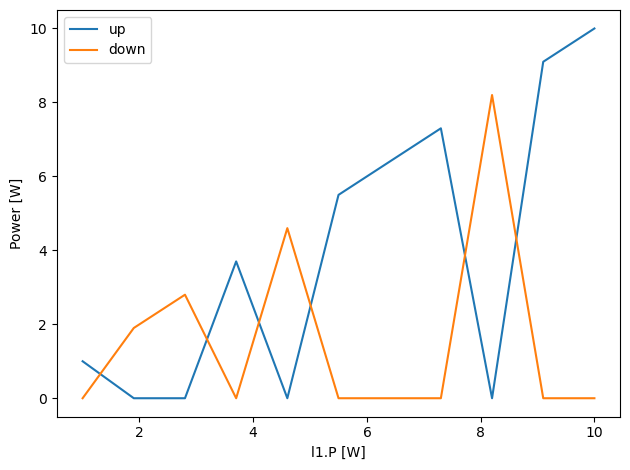

In [1]:
import random

from finesse.components.workspace import ConnectorWorkspace

import finesse
from finesse.analysis.actions import Xaxis
from finesse.components.general import Connector
from finesse.script.spec import KATSPEC, make_element


class DiceRoll(Connector):
    def __init__(self, name):
        super().__init__(name)
        self.p1 = self._create_optical_port("p1", add_input=True, add_output=True)
        self.p2 = self._create_optical_port("p2", add_input=True, add_output=True)
        self.p3 = self._create_optical_port("p3", add_input=True, add_output=True)
        self._register_node_coupling(
            "P1i_P2o",
            self.p1.i,
            self.p2.o,
        )
        self._register_node_coupling(
            "P1i_P3o",
            self.p1.i,
            self.p3.o,
        )

    def _get_workspace(self, sim):
        ws = ConnectorWorkspace(self, sim)
        ws.carrier.add_fill_function(self._fill_optical_matrix, refill=True)
        return ws

    def _fill_optical_matrix(self, ws):
        matrix = ws.sim.carrier
        conn = ws.carrier.connections
        if random.random() > 0.5:
            p1_p2_coupling = 1.0
            p1_p3_coupling = 0.0
        else:
            p1_p2_coupling = 0.0
            p1_p3_coupling = 1.0

        with matrix.component_edge_fill3(ws.owner_id, conn.P1i_P2o_idx, 0, 0) as mat:
            mat[:] = p1_p2_coupling

        with matrix.component_edge_fill3(ws.owner_id, conn.P1i_P3o_idx, 0, 0) as mat:
            mat[:] = p1_p3_coupling


KATSPEC.register_element(make_element(DiceRoll, "droll"))

model = finesse.Model("""
laser l1
s s1 l1.p1 dice.p1
droll dice                      
pd up dice.p2.o
pd down dice.p3.o
""")

sol = model.run(Xaxis(model.l1.P, "lin", 1, 10, 10))
sol.plot();